# ai-detector — phát hiện giọng nói giả tiếng Việt

Notebook **tự chứa toàn bộ mã nguồn** (37 file, 61 KB nhúng sẵn) —
không cần clone repo, không cần dataset chứa code. Import lên Kaggle là chạy được.

```
REAL (giọng thật tiếng Việt)
   └── Piper · Kokoro · OmniVoice ──> FAKE
                 └── augmentation ──> WavLM ──> Classifier ──> REAL / FAKE
```

## Notebook chia làm hai phần — chạy phần A trước

| | Làm gì | Khi nào chạy |
|---|---|---|
| **PHẦN A** | tạo dataset: ingest → generate → **kiểm tra + nghe thử** → đóng gói | chạy trước, xem dataset có ổn không |
| **PHẦN B** | huấn luyện: split → augment → WavLM → classifier → đánh giá | chỉ chạy khi dataset đã ưng ý |

Phần A có công tắc **`SMOKE = True`**: chạy thử ~40 mẫu trong vài phút để xem
engine nào hoạt động, audio nghe ra sao. Ưng rồi mới đặt `SMOKE = False` chạy thật.

## Cần bật trong panel bên phải

| Mục | Đặt thành | Vì sao |
|---|---|---|
| **Accelerator** | `GPU T4 x2` hoặc `P100` | OmniVoice (voice cloning) không chạy nổi trên CPU |
| **Internet** | `On` | tải WavLM, giọng Piper/Kokoro, cài thư viện |

Rồi **Add Input → Datasets** một bộ giọng thật tiếng Việt (VIVOS, Common Voice vi…).
Pipeline tự nhận diện định dạng — không cần chỉnh gì thêm.

> Phiên Kaggle ~9 giờ rồi **xoá sạch `/kaggle/working`**. Ô cuối phần A đóng gói
> dataset thành một zip để bạn lưu ra Dataset, phiên sau train mà khỏi tạo lại.

## 0. Chuẩn bị

In [22]:
# Toàn bộ package aidetector + configs, nén tar.gz rồi base64.
# sha256(payload) = 1e874070cacd488d…
_PAYLOAD = (
    "..."
    "zefmc/O5+dx8bj43n5vPzaf4+QNB9EsZAJgDAA=="
)

import base64, hashlib, importlib, io, os, shutil, sys, tarfile
from pathlib import Path

_raw = base64.b64decode(_PAYLOAD)
assert hashlib.sha256(_raw).hexdigest() == "1e874070cacd488de269c33f236a874483f198e065527f73b2f229fe81429b36", "payload hỏng khi sao chép notebook"

WORK = Path("/kaggle/working/ai-detector")
WORK.mkdir(parents=True, exist_ok=True)

# Xoá sạch cây mã nguồn cũ trước khi bung: chạy đè lên bản cũ sẽ để sót những file
# đã bị bỏ ở bản mới, và để lại __pycache__ cũ.
for _old in ("aidetector", "configs"):
    shutil.rmtree(WORK / _old, ignore_errors=True)

with tarfile.open(fileobj=io.BytesIO(_raw), mode="r:gz") as _tf:
    try:
        _tf.extractall(WORK, filter="data")     # Python >= 3.12
    except TypeError:
        _tf.extractall(WORK)

os.chdir(WORK)
if str(WORK) not in sys.path:
    sys.path.insert(0, str(WORK))

# Kernel Kaggle sống xuyên suốt nhiều lần chạy. Nếu phiên trước đã import
# aidetector, Python giữ nguyên module cũ trong sys.modules và lờ đi mã vừa bung —
# biểu hiện là những lỗi rất khó hiểu kiểu "cannot import name X" dù X có trong
# file. Phải gỡ chúng ra để lần import sau đọc lại từ đĩa.
_stale = [m for m in sys.modules if m == "aidetector" or m.startswith("aidetector.")]
for _m in _stale:
    del sys.modules[_m]
importlib.invalidate_caches()

CFG = "configs/kaggle.yaml"


# Chạy một stage của pipeline và DỪNG notebook ngay nếu nó lỗi.
# Không dùng `!python -m aidetector ...`: trong Jupyter, lệnh shell lỗi vẫn để
# notebook chạy tiếp các ô sau, nên một stage hỏng sẽ âm thầm kéo theo cả loạt lỗi
# vô nghĩa ở dưới — hoặc tệ hơn, chạy tiếp trên dữ liệu cũ còn sót lại.
#
# `optional=True` dành cho bước không bắt buộc (vd một engine sinh fake cần GPU
# hoặc cần quyền tải checkpoint): hỏng thì báo rồi đi tiếp, vì dữ liệu đã có từ
# các bước trước vẫn dùng được.
def run(*args, optional=False):
    import subprocess

    cmd = [sys.executable, "-m", "aidetector", *[str(a) for a in args], "-c", CFG]
    print("$ python -m aidetector " + " ".join(str(a) for a in args) + f" -c {CFG}\n")
    if subprocess.run(cmd).returncode == 0:
        return True
    if optional:
        print(f"\n⚠ Bước tuỳ chọn {args[0]!r} không chạy được — bỏ qua, đi tiếp.")
        return False
    raise SystemExit(f"✖ Stage {args[0]!r} thất bại — xem log ngay phía trên, "
                     f"đừng chạy tiếp các ô sau.")


print(f"Đã bung {len(_raw) / 1024:.0f} KB mã nguồn vào {WORK}")
if _stale:
    print(f"Đã gỡ {len(_stale)} module aidetector cũ khỏi bộ nhớ kernel")

Đã bung 61 KB mã nguồn vào /kaggle/working/ai-detector
Đã gỡ 13 module aidetector cũ khỏi bộ nhớ kernel


Cài thư viện — **lượt 1: Piper + Kokoro**.

Kokoro chạy trên `transformers` 4.x còn Kaggle cài sẵn 5.x, nên phải ghim lại sau
khi cài. OmniVoice cần đúng chiều ngược lại (`>=5.3`) nên để dành cho lượt 2 ở mục
A3b — hai engine đó không sống chung được trong một môi trường.

In [23]:
!pip install -q -r requirements.txt
!apt-get -qq install -y ffmpeg > /dev/null 2>&1 || true   # cần cho augment MP3/AAC

!pip install -q piper-tts                                                 || true
!pip install -q git+https://github.com/iamdinhthuan/Kokoro-Vietnamese.git || true
!pip install -q "transformers>=4.48,<5"

import transformers, torch
print(f"transformers {transformers.__version__} · torch {torch.__version__} "
      f"· CUDA {torch.cuda.is_available()}")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
omnivoice 0.2.1 requires transformers>=5.3.0, but you have transformers 4.57.6 which is incompatible.
transformers 4.57.6 · torch 2.10.0+cu128 · CUDA True


In [24]:
run("info")

$ python -m aidetector info -c configs/kaggle.yaml

ai-detector 2.0.0
Chuẩn audio : 16000 Hz · mono · WAV/PCM_16 · 3-10s · RMS -23 dBFS
Thiết bị    : cuda   ffmpeg: có
Môi trường  : kaggle · work=/kaggle/working · input=/kaggle/input · đĩa≈20GB · phiên≈9h · trống 19.4 GB
Dataset mount: datasets

Nguồn dữ liệu (ingest):
  common_voice     Mozilla Common Voice (clips/ + validated.tsv)
  folder           Thư mục audio bất kỳ (speaker = thư mục con, transcript tự dò)
  hf               Dataset audio trên HuggingFace Hub (dùng --hf <repo_id>)
  labeled_folder   Dataset đã chia sẵn real/ và fake/ (hoặc bonafide/ và spoof/)
  vivos            VIVOS Vietnamese speech corpus (waves/ + prompts.txt)

Engine sinh fake (generate):
  ✔ kokoro         [tts] Kokoro-Vietnamese (82M, 13 giọng vi) — chạy được trên CPU
  ✖ omnivoice      [clone] OmniVoice zero-shot voice cloning (cần audio tham chiếu; nên có GPU/MPS)  (omnivoice cần transformers >=5.3, đang có 4.57 → pip install "transformers>=5.3")
  ✔ p

True

---
# PHẦN A — Tạo dataset

Mục tiêu của phần này là ra được một corpus **đạt chuẩn và cân bằng**, kiểm tra tận
tai trước khi tốn thời gian huấn luyện.

## A1. Chọn dataset thật + đặt quy mô

`SMOKE = True` chạy thử nhanh (~40 real + 40 fake, vài phút). Xem kết quả ở A4–A5,
ưng rồi đặt `SMOKE = False` và chạy lại từ A2 để làm thật.

In [25]:
import logging
from pathlib import Path

from aidetector.ingest import detect_adapter
from aidetector.ingest.base import describe_directory

SMOKE = True        # ← True: chạy thử nhanh · False: chạy thật
RAW = None          # ← đặt tay nếu tự dò không đúng, vd "/kaggle/input/vivos"

if SMOKE:
    N_REAL, PER_SPEAKER, N_FAKE_TTS, N_FAKE_CLONE = 60, 8, 30, 15
else:
    N_REAL, PER_SPEAKER, N_FAKE_TTS, N_FAKE_CLONE = 4000, 120, 1200, 800

# Soi TỪNG dataset đang mount rồi chọn cái dùng được, thay vì lấy bừa cái đầu tiên:
# một dataset rỗng hay sai định dạng đứng đầu bảng chữ cái sẽ làm hỏng cả phiên.
logging.getLogger("aidetector.ingest").setLevel(logging.WARNING)
mounted = sorted(p for p in Path("/kaggle/input").glob("*") if p.is_dir())
if not mounted:
    raise SystemExit("Chưa add dataset nào — Add Input → Datasets ở panel bên phải.")

print("Dataset đang mount:")
usable = []
for folder in mounted:
    try:
        adapter, score, effective = detect_adapter(folder)
    except ValueError as exc:
        reason = next((l.strip() for l in str(exc).splitlines()[1:] if l.strip()),
                      "không nhận diện được")
        print(f"  ✖ {folder.name:<26} {reason}")
        continue
    where = "" if effective == folder else f" tại {effective.relative_to(folder)}/"
    print(f"  ✔ {folder.name:<26} {adapter.name} (điểm {score:.2f}){where}")
    usable.append((score, folder))

if RAW is None:
    if not usable:
        raise SystemExit(
            "Không dataset nào chứa audio đọc được. Chi tiết:\n"
            + "\n".join(f"[{p.name}]\n" + describe_directory(p) for p in mounted)
        )
    usable.sort(key=lambda pair: -pair[0])
    RAW = str(usable[0][1])

print(f"\nNguồn REAL : {RAW}")
print(f"Chế độ     : {'CHẠY THỬ' if SMOKE else 'CHẠY THẬT'}")
print(f"Quy mô     : {N_REAL} real · {N_FAKE_TTS} fake TTS · {N_FAKE_CLONE} fake cloning")

Dataset đang mount:
  ✔ datasets                   vivos (điểm 1.00) tại kynthesis/vivos-vietnamese-speech-corpus-for-asr/vivos/

Nguồn REAL : /kaggle/input/datasets
Chế độ     : CHẠY THỬ
Quy mô     : 60 real · 30 fake TTS · 15 fake cloning


## A2. REAL — nạp giọng thật về chuẩn corpus

`ingest` tự nhận diện loại dataset (VIVOS / Common Voice / thư mục wav / real+fake
chia sẵn) rồi ép mọi file về đúng một chuẩn:

| | |
|---|---|
| Sample rate · kênh | 16 000 Hz · mono |
| Định dạng | WAV, 16-bit PCM |
| Độ dài | 3–10 giây (file dài hơn cắt thành nhiều đoạn) |
| Mức âm lượng | RMS −23 dBFS, trần peak −1 dBFS |
| Im lặng · clipping · NaN | cắt bớt · không được có · không được có |

Real và fake dùng **chung** chuỗi chuẩn hoá này, nên mô hình không thể phân biệt hai
lớp bằng định dạng hay độ to.

In [26]:
run("ingest", RAW, "--limit", N_REAL, "--per-speaker", PER_SPEAKER)

$ python -m aidetector ingest /kaggle/input/datasets --limit 60 --per-speaker 8 -c configs/kaggle.yaml



09:27:56 INFO    aidetector.env | Môi trường: kaggle · work=/kaggle/working · input=/kaggle/input · đĩa≈20GB · phiên≈9h · còn trống 19.4 GB
09:27:56 WARNING aidetector.env | Dữ liệu trong /kaggle/working sẽ MẤT khi phiên kết thúc. Nhớ lưu corpus/ + checkpoints/ ra Kaggle Dataset hoặc tải về trước khi hết phiên (~9.0 giờ).
09:27:56 INFO    aidetector.ingest | Nhận diện dataset: vivos (điểm 1.00) tại kynthesis/vivos-vietnamese-speech-corpus-for-asr/vivos/
09:27:56 INFO    aidetector.ingest | Bỏ qua 3 tầng thư mục bọc ngoài — dùng /kaggle/input/datasets/kynthesis/vivos-vietnamese-speech-corpus-for-asr/vivos
09:27:56 INFO    aidetector.cli | ▶ ingest vivos
ingest:vivos:   5%|▍         | 607/12420 [00:04<01:36, 122.42it/s]
09:28:01 INFO    aidetector.ingest | Ingest vivos: giữ 60 · bỏ (không đạt chuẩn) 210 · đã có sẵn 60 · 16 speaker
09:28:01 INFO    aidetector.cli | ✔ ingest vivos — 5s
09:28:01 INFO    aidetector.corpus.manifest | Đã ghi /kaggle/working/corpus/manifest.csv (208 bản ghi)


Corpus: /kaggle/working/corpus
  Tổng: 208 utt · 0.22 giờ · real=152 fake=56 (augment: 55)
  Nguồn real: vivos=152
  Generator : kokoro:diem_trinh=5, kokoro:hung_thinh=5, kokoro:mai_linh=2, kokoro:manh_dung=3, kokoro:my_yen=2, kokoro:ngoc_huyen=4, kokoro:phat_tai=4, kokoro:thanh_dat=5, omnivoice=17, piper:vi_VN-vais1000-medium=9
  test        : real=76 fake=7
  train       : real=68 fake=47
  val         : real=8 fake=2
  Speaker real: 16


True

In [27]:
# Chặn sớm: ba điều kiện dưới đây mà không đạt thì mọi bước sau đều vô nghĩa.
from aidetector.config import Config
from aidetector.corpus.manifest import Manifest

manifest = Manifest.load(Config.load(CFG)["paths.corpus"], required=True)
n_real = len(manifest.reals)
n_speakers = len(manifest.speakers("real"))
n_text = sum(1 for r in manifest.reals if r.text)

print(f"real={n_real} · speaker={n_speakers} · có transcript={n_text}")
problems = []
if n_real < 10:
    problems.append(f"Chỉ nạp được {n_real} audio thật — kiểm tra RAW có trỏ đúng dataset không.")
if n_speakers < 3:
    problems.append(
        f"Chỉ có {n_speakers} speaker — không chia được train/val/test speaker-disjoint. "
        "Adapter có thể đang đọc sai cấu trúc thư mục.")
if n_text == 0:
    problems.append(
        "Không có transcript nào — fake sẽ phải dùng câu dự phòng và không ghép cặp "
        "được với real. Hãy dùng bộ dữ liệu có transcript (VIVOS, Common Voice).")
if problems:
    raise SystemExit("DỪNG LẠI:\n" + "\n".join(f"  • {p}" for p in problems))
print("✔ dataset thật đủ điều kiện để sinh fake")

real=152 · speaker=16 · có transcript=152
✔ dataset thật đủ điều kiện để sinh fake


## A3. FAKE — sinh audio giả

Mỗi audio giả sinh từ **chính transcript và speaker của một utterance thật**, nên
luôn có bản real đối chứng cùng nội dung cùng giọng — mô hình không thể phân loại
theo chủ đề câu nói hay theo danh tính người nói.

`generate` là idempotent: dừng giữa chừng rồi chạy lại chỉ sinh phần còn thiếu.

In [28]:
# Hai engine TTS giọng cố định — nhanh, chạy được cả trên CPU.
run("generate", "--engines", "piper", "kokoro", "--count", N_FAKE_TTS)

$ python -m aidetector generate --engines piper kokoro --count 30 -c configs/kaggle.yaml



09:28:03 INFO    aidetector.env | Môi trường: kaggle · work=/kaggle/working · input=/kaggle/input · đĩa≈20GB · phiên≈9h · còn trống 19.4 GB
09:28:03 WARNING aidetector.env | Dữ liệu trong /kaggle/working sẽ MẤT khi phiên kết thúc. Nhớ lưu corpus/ + checkpoints/ ra Kaggle Dataset hoặc tải về trước khi hết phiên (~9.0 giờ).
09:28:04 INFO    aidetector.cli | ▶ generate piper (30 mẫu)
09:28:04 INFO    aidetector.generate | Engine piper (tts) · 30 mẫu · 1 giọng · device=cuda
09:28:04 INFO    aidetector.generate.piper | Nạp Piper voice vi_VN-vais1000-medium.onnx
generate:piper: 100%|██████████| 30/30 [00:07<00:00,  4.15it/s]
09:28:12 INFO    aidetector.generate | Engine piper: tạo 0 · lỗi 0 · không đạt chuẩn 28 · đã có 2
09:28:12 WARNING aidetector.generate | 28/28 mẫu bị loại vì không đạt chuẩn 3–10 giây. Câu quá ngắn thì audio sinh ra cũng ngắn — chỉnh `generate.min_words` (đang 6) lên cao hơn để chọn câu dài hơn.
09:28:12 INFO    aidetector.cli | ✔ generate piper (30 mẫu) — 8s
09:28:12 IN

Corpus: /kaggle/working/corpus
  Tổng: 225 utt · 0.23 giờ · real=152 fake=73 (augment: 55)
  Nguồn real: vivos=152
  Generator : kokoro:diem_trinh=7, kokoro:hung_thinh=6, kokoro:mai_linh=3, kokoro:manh_dung=5, kokoro:my_yen=5, kokoro:ngoc_huyen=6, kokoro:phat_tai=6, kokoro:thanh_dat=8, kokoro:tuan_ngoc=1, omnivoice=17, piper:vi_VN-vais1000-medium=9
  test        : real=76 fake=16
  train       : real=68 fake=54
  val         : real=8 fake=3
  Speaker real: 16


True

### A3b. OmniVoice — lượt hai, phải nâng transformers trước

Đây là engine **giá trị nhất về mặt dữ liệu**: nó clone thẳng giọng của chính
speaker thật, nên audio giả trùng với real **cả nội dung lẫn danh tính người nói**.
Piper và Kokoro chỉ có giọng cố định — nếu dataset chỉ có hai engine đó, mô hình rất
dễ học lối tắt *"nghe thấy mấy giọng này ⇒ fake"* thay vì học dấu vết tổng hợp.

Nhưng hai engine **không sống chung được trong một môi trường**:

| Engine | Cần |
|---|---|
| `kokoro` | `transformers <5` |
| `omnivoice` | `transformers >=5.3` |

Vì `generate` là idempotent và corpus cộng dồn, ta chạy hai lượt: Kokoro xong rồi
mới nâng transformers lên cho OmniVoice. Sau ô này Kokoro không dùng được nữa —
không sao, nó đã sinh xong ở trên. Backbone WavLM chạy tốt trên cả hai nhánh nên
phần huấn luyện không bị ảnh hưởng.

Checkpoint mặc định là **`splendor1811/omnivoice-vietnamese`** — fine-tune riêng cho
tiếng Việt và là repo công khai nên tải được ngay, không cần token. Bản gốc đa ngữ
`k2-fsa/OmniVoice` đọc tiếng Việt kém hơn rõ rệt; chỉ đổi sang nó khi cần ngôn ngữ khác:

```python
run("generate", "--engines", "omnivoice", "--count", N_FAKE_CLONE,
    "--set", "generate.options.omnivoice.checkpoint=k2-fsa/OmniVoice", optional=True)
```

In [29]:
!pip install -q omnivoice "transformers>=5.3"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
kokoro-vietnamese 0.1.0 requires transformers<5,>=4.48, but you have transformers 5.15.0 which is incompatible.


In [30]:
run("info")     # xác nhận omnivoice đã ✔ trước khi tốn thời gian sinh

$ python -m aidetector info -c configs/kaggle.yaml



09:28:59 INFO    numexpr.utils | NumExpr defaulting to 4 threads.


ai-detector 2.0.0
Chuẩn audio : 16000 Hz · mono · WAV/PCM_16 · 3-10s · RMS -23 dBFS
Thiết bị    : cuda   ffmpeg: có
Môi trường  : kaggle · work=/kaggle/working · input=/kaggle/input · đĩa≈20GB · phiên≈9h · trống 19.4 GB
Dataset mount: datasets

Nguồn dữ liệu (ingest):
  common_voice     Mozilla Common Voice (clips/ + validated.tsv)
  folder           Thư mục audio bất kỳ (speaker = thư mục con, transcript tự dò)
  hf               Dataset audio trên HuggingFace Hub (dùng --hf <repo_id>)
  labeled_folder   Dataset đã chia sẵn real/ và fake/ (hoặc bonafide/ và spoof/)
  vivos            VIVOS Vietnamese speech corpus (waves/ + prompts.txt)

Engine sinh fake (generate):
  ✖ kokoro         [tts] Kokoro-Vietnamese (82M, 13 giọng vi) — chạy được trên CPU  (kokoro-vietnamese cần transformers <5, đang có 5.15 → pip install "transformers>=4.48,<5")
  ✔ omnivoice      [clone] OmniVoice zero-shot voice cloning (cần audio tham chiếu; nên có GPU/MPS)
  ✔ piper          [tts] Piper TTS (ONNX, CPU nh

True

In [31]:
# optional=True: OmniVoice cần GPU và cần tải checkpoint vài GB. Hỏng thì bỏ qua,
# 30 audio giả của Piper/Kokoro ở trên vẫn đủ để đi tiếp phần B.
run("generate", "--engines", "omnivoice", "--count", N_FAKE_CLONE, optional=True)

$ python -m aidetector generate --engines omnivoice --count 15 -c configs/kaggle.yaml



09:29:03 INFO    aidetector.env | Môi trường: kaggle · work=/kaggle/working · input=/kaggle/input · đĩa≈20GB · phiên≈9h · còn trống 19.4 GB
09:29:03 WARNING aidetector.env | Dữ liệu trong /kaggle/working sẽ MẤT khi phiên kết thúc. Nhớ lưu corpus/ + checkpoints/ ra Kaggle Dataset hoặc tải về trước khi hết phiên (~9.0 giờ).
09:29:09 INFO    numexpr.utils | NumExpr defaulting to 4 threads.
09:29:09 INFO    aidetector.cli | ▶ generate omnivoice (15 mẫu)
09:29:09 INFO    aidetector.generate | Engine omnivoice (clone) · 15 mẫu · 1 giọng · device=cuda
09:29:09 INFO    aidetector.generate.omnivoice | Nạp OmniVoice splendor1811/omnivoice-vietnamese (device=cuda, dtype=torch.float16)
Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
09:29:10 WARNING huggingface_hub.utils._http | Warning: You are sending unauthenticated requests to the HF Hub. Please set a

Corpus: /kaggle/working/corpus
  Tổng: 232 utt · 0.24 giờ · real=152 fake=80 (augment: 55)
  Nguồn real: vivos=152
  Generator : kokoro:diem_trinh=7, kokoro:hung_thinh=6, kokoro:mai_linh=3, kokoro:manh_dung=5, kokoro:my_yen=5, kokoro:ngoc_huyen=6, kokoro:phat_tai=6, kokoro:thanh_dat=8, kokoro:tuan_ngoc=1, omnivoice=24, piper:vi_VN-vais1000-medium=9
  test        : real=76 fake=22
  train       : real=68 fake=55
  val         : real=8 fake=3
  Speaker real: 16


True

## A4. Kiểm tra dataset

Ba việc: soi toàn corpus xem có file nào phạm chuẩn, xem thống kê, và **nghe thử**.

In [32]:
run("validate")

$ python -m aidetector validate -c configs/kaggle.yaml



09:29:44 INFO    aidetector.env | Môi trường: kaggle · work=/kaggle/working · input=/kaggle/input · đĩa≈20GB · phiên≈9h · còn trống 19.4 GB
09:29:44 WARNING aidetector.env | Dữ liệu trong /kaggle/working sẽ MẤT khi phiên kết thúc. Nhớ lưu corpus/ + checkpoints/ ra Kaggle Dataset hoặc tải về trước khi hết phiên (~9.0 giờ).
09:29:44 INFO    aidetector.cli | Kiểm tra 232 bản ghi theo chuẩn: 16000 Hz · mono · WAV/PCM_16 · 3-10s · RMS -23 dBFS
validate: 100%|██████████| 232/232 [00:01<00:00, 128.77it/s]


Corpus: /kaggle/working/corpus
  Tổng: 232 utt · 0.24 giờ · real=152 fake=80 (augment: 55)
  Nguồn real: vivos=152
  Generator : kokoro:diem_trinh=7, kokoro:hung_thinh=6, kokoro:mai_linh=3, kokoro:manh_dung=5, kokoro:my_yen=5, kokoro:ngoc_huyen=6, kokoro:phat_tai=6, kokoro:thanh_dat=8, kokoro:tuan_ngoc=1, omnivoice=24, piper:vi_VN-vais1000-medium=9
  test        : real=76 fake=22
  train       : real=68 fake=55
  val         : real=8 fake=3
  Speaker real: 16

✔ Toàn bộ corpus đạt chuẩn.


True

In [33]:
# Thống kê chi tiết: số lượng, thời lượng, cân bằng hai lớp, phủ speaker
from collections import Counter

from aidetector.config import Config
from aidetector.corpus.manifest import Manifest

cfg = Config.load(CFG)
manifest = Manifest.load(cfg["paths.corpus"], required=True)
stats = manifest.stats()

n_real = stats["by_label"].get("real", 0)
n_fake = stats["by_label"].get("fake", 0)
print(f"Tổng      : {stats['total']} utt · {stats['hours']} giờ")
print(f"REAL/FAKE : {n_real} / {n_fake}"
      + (f"   ⚠ lệch {max(n_real, n_fake) / max(min(n_real, n_fake), 1):.1f}×"
         if min(n_real, n_fake) and max(n_real, n_fake) / min(n_real, n_fake) > 1.3 else "   ✔ cân bằng"))
print(f"Speaker   : {stats['speakers_real']}")

print("\nTheo engine:")
for name, count in sorted(stats["by_generator"].items()):
    print(f"  {name:<42} {count}")

durations = [r.duration for r in manifest]
print(f"\nĐộ dài    : {min(durations):.1f}–{max(durations):.1f}s "
      f"(trung bình {sum(durations) / len(durations):.1f}s)")

paired = sum(1 for r in manifest.fakes if r.ref_utt_id in manifest)
print(f"Ghép cặp  : {paired}/{len(manifest.fakes)} fake có real đối chứng cùng nội dung")

no_text = sum(1 for r in manifest.reals if not r.text)
if no_text:
    print(f"⚠ {no_text} utt real không có transcript — không dùng làm khuôn sinh fake được")

Tổng      : 232 utt · 0.24 giờ
REAL/FAKE : 152 / 80   ⚠ lệch 1.9×
Speaker   : 16

Theo engine:
  kokoro:diem_trinh                          7
  kokoro:hung_thinh                          6
  kokoro:mai_linh                            3
  kokoro:manh_dung                           5
  kokoro:my_yen                              5
  kokoro:ngoc_huyen                          6
  kokoro:phat_tai                            6
  kokoro:thanh_dat                           8
  kokoro:tuan_ngoc                           1
  omnivoice                                  24
  piper:vi_VN-vais1000-medium                9

Độ dài    : 3.0–6.4s (trung bình 3.7s)
Ghép cặp  : 80/80 fake có real đối chứng cùng nội dung


In [34]:
# NGHE THỬ: mỗi cặp là cùng một câu, cùng một speaker — real trước, fake sau.
from IPython.display import Audio, display

pairs = []
for fake in manifest.fakes:
    real = manifest.get(fake.ref_utt_id)
    if real is not None:
        pairs.append((real, fake))
    if len(pairs) >= 3:
        break

if not pairs:
    print("Chưa có fake nào — chạy lại ô A3.")
for real, fake in pairs:
    print("=" * 90)
    print(f"Câu    : {real.text[:110]}")
    print(f"Speaker: {real.speaker}   ·   engine: {fake.generator}")
    print(f"REAL ({real.duration:.1f}s)")
    display(Audio(str(manifest.abs_path(real))))
    print(f"FAKE ({fake.duration:.1f}s)")
    display(Audio(str(manifest.abs_path(fake))))

Câu    : NGỌN LỬA BẠO ĐỘNG Ở TRUNG ĐÔNG VÀ PHÁ VỠ LỘ TRÌNH HÒA BÌNH
Speaker: vivosdev01   ·   engine: kokoro:manh_dung
REAL (5.2s)


FAKE (3.4s)


Câu    : DI TÍCH CÓ BẢY PHỖNG ÔNG VÀ HAI PHỖNG BÀ ĐƯỢC LÀM BẰNG GỖ MÍT
Speaker: vivosdev01   ·   engine: kokoro:thanh_dat
REAL (4.5s)


FAKE (3.8s)


Câu    : NGỌN LỬA BẠO ĐỘNG Ở TRUNG ĐÔNG VÀ PHÁ VỠ LỘ TRÌNH HÒA BÌNH
Speaker: vivosdev01   ·   engine: kokoro:hung_thinh
REAL (5.2s)


FAKE (3.1s)


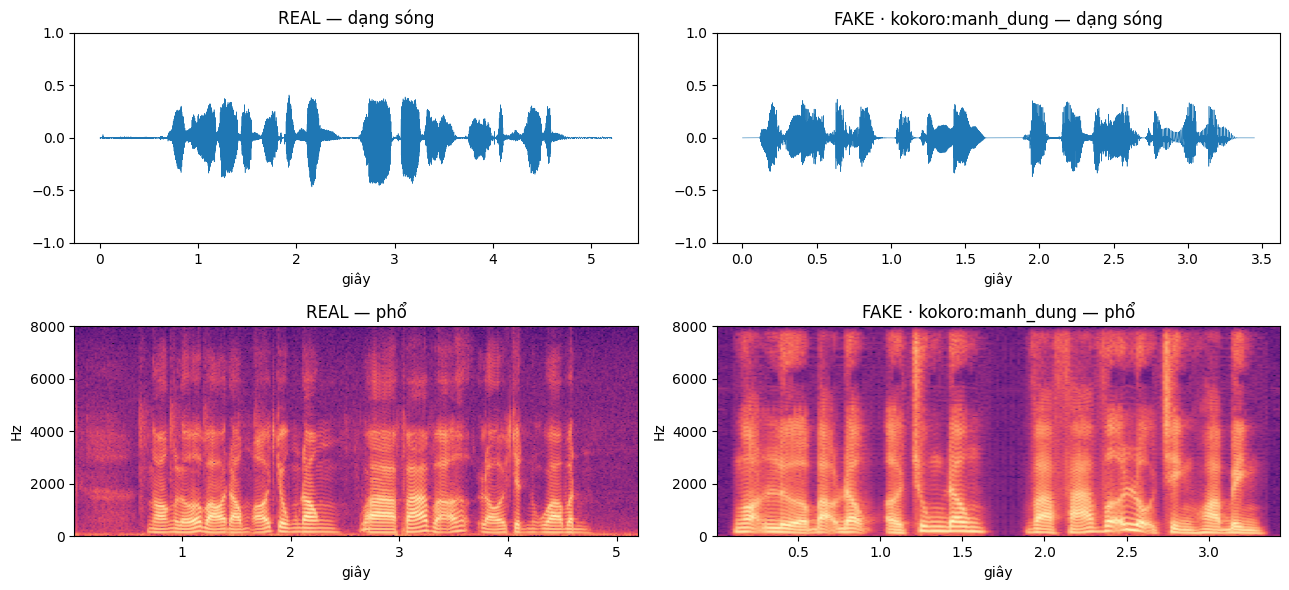

In [35]:
# Dạng sóng + phổ của một cặp — fake thường mượt và đều hơn ở vùng tần số cao.
import matplotlib.pyplot as plt
import numpy as np

from aidetector.corpus.spec import load_audio

if pairs:
    real, fake = pairs[0]
    fig, axes = plt.subplots(2, 2, figsize=(13, 6))
    for col, (rec, title) in enumerate([(real, "REAL"), (fake, f"FAKE · {fake.generator}")]):
        audio = load_audio(manifest.abs_path(rec), 16_000)
        axes[0, col].plot(np.arange(len(audio)) / 16_000, audio, lw=0.4)
        axes[0, col].set(title=f"{title} — dạng sóng", xlabel="giây", ylim=(-1, 1))
        axes[1, col].specgram(audio, Fs=16_000, NFFT=512, noverlap=256, cmap="magma")
        axes[1, col].set(title=f"{title} — phổ", xlabel="giây", ylabel="Hz")
    fig.tight_layout()
    plt.show()

## A5. Đóng gói dataset

`/kaggle/working` bị xoá khi hết phiên, và commit output với hàng chục nghìn file wav
rời rạc thì rất chậm — nên gói tất cả vào **một** zip.

Chạy xong notebook: **Output → New Dataset**. Phiên sau chỉ cần add dataset đó rồi
`unpack`, khỏi phải ingest và generate lại.

In [36]:
run("pack", "--out", "/kaggle/working/corpus.zip")
!ls -lh /kaggle/working/corpus.zip

$ python -m aidetector pack --out /kaggle/working/corpus.zip -c configs/kaggle.yaml



09:29:48 INFO    aidetector.cli | ▶ pack → /kaggle/working/corpus.zip
pack: 100%|██████████| 232/232 [00:00<00:00, 2429.80it/s]
09:29:48 INFO    aidetector.packaging | Đã gói 232 bản ghi → /kaggle/working/corpus.zip (26.3 MB)
09:29:48 INFO    aidetector.cli | ✔ pack → /kaggle/working/corpus.zip — 0s


-rw-r--r-- 1 root root 27M Aug 13 09:29 /kaggle/working/corpus.zip


> ### Dừng lại ở đây nếu chỉ cần dataset
>
> Xem lại A4: hai lớp có cân bằng không, engine nào sinh được bao nhiêu, nghe thử
> thấy hợp lý chưa. Nếu đang ở `SMOKE = True` thì giờ đặt `SMOKE = False` ở ô A1 và
> chạy lại A2–A5 để làm thật. Ưng rồi mới sang phần B.

---
# PHẦN B — Huấn luyện

Chạy phần này khi dataset đã ưng. Nếu dataset đến từ phiên trước, chạy ô ngay dưới
để bung nó ra rồi bỏ qua toàn bộ phần A.

In [37]:
# Chỉ chạy khi dùng lại dataset của phiên trước:
# run("unpack", "/kaggle/input/<tên-dataset>/corpus.zip")

## B1. Chia tập → augment

`split` chạy **trước** `augment`: bản augment chỉ sinh cho train và bám đúng split
của bản gốc, còn val/test giữ audio sạch để số đo phản ánh dữ liệu thật. Chia
speaker-disjoint nên không có speaker nào xuất hiện ở hai tập.

Thêm `--holdout omnivoice` nếu muốn giữ hẳn một engine riêng cho test — đó là phép
đo sát thực tế nhất: mô hình có bắt được engine **chưa từng thấy** hay không.

In [38]:
run("split")
run("augment", "--copies", 1)

$ python -m aidetector split -c configs/kaggle.yaml



09:29:50 INFO    aidetector.env | Môi trường: kaggle · work=/kaggle/working · input=/kaggle/input · đĩa≈20GB · phiên≈9h · còn trống 19.4 GB
09:29:50 WARNING aidetector.env | Dữ liệu trong /kaggle/working sẽ MẤT khi phiên kết thúc. Nhớ lưu corpus/ + checkpoints/ ra Kaggle Dataset hoặc tải về trước khi hết phiên (~9.0 giờ).
09:29:50 INFO    aidetector.cli | ▶ split
09:29:50 INFO    aidetector.splits | Không có rò rỉ speaker giữa các split ✔
09:29:50 INFO    aidetector.splits |   train:   164 utt (real=107 fake=57) · 11 speaker
09:29:50 INFO    aidetector.splits |   val  :    35 utt (real=21 fake=14) · 2 speaker
09:29:50 INFO    aidetector.splits |   test :    33 utt (real=24 fake=9) · 3 speaker
09:29:50 INFO    aidetector.cli | ✔ split — 0s
09:29:50 INFO    aidetector.corpus.manifest | Đã ghi /kaggle/working/corpus/manifest.csv (232 bản ghi)


$ python -m aidetector augment --copies 1 -c configs/kaggle.yaml



09:29:52 INFO    aidetector.env | Môi trường: kaggle · work=/kaggle/working · input=/kaggle/input · đĩa≈20GB · phiên≈9h · còn trống 19.4 GB
09:29:52 WARNING aidetector.env | Dữ liệu trong /kaggle/working sẽ MẤT khi phiên kết thúc. Nhớ lưu corpus/ + checkpoints/ ra Kaggle Dataset hoặc tải về trước khi hết phiên (~9.0 giờ).
09:29:52 INFO    aidetector.cli | ▶ augment
augment: 100%|██████████| 121/121 [00:12<00:00,  9.53it/s]
09:30:05 INFO    aidetector.augment | Augment: tạo 65 bản (real=45, fake=20) · bỏ 0 · đã có 43
09:30:05 WARNING aidetector.augment | Số bản augment giữa hai lớp lệch nhau (real=45, fake=20) — augmentation có thể trở thành manh mối. Cân nhắc cân bằng lại corpus trước khi augment.
09:30:05 INFO    aidetector.cli | ✔ augment — 12s
09:30:05 INFO    aidetector.corpus.manifest | Đã ghi /kaggle/working/corpus/manifest.csv (297 bản ghi)


Corpus: /kaggle/working/corpus
  Tổng: 297 utt · 0.31 giờ · real=197 fake=100 (augment: 120)
  Nguồn real: vivos=197
  Generator : kokoro:diem_trinh=9, kokoro:hung_thinh=7, kokoro:mai_linh=4, kokoro:manh_dung=6, kokoro:my_yen=7, kokoro:ngoc_huyen=8, kokoro:phat_tai=8, kokoro:thanh_dat=11, kokoro:tuan_ngoc=1, omnivoice=30, piper:vi_VN-vais1000-medium=9
  test        : real=24 fake=9
  train       : real=152 fake=77
  val         : real=21 fake=14
  Speaker real: 16


True

## B2. WavLM → Classifier

Embedding cache theo `utt_id` nên chạy lại chỉ trích phần mới. Đổi backbone chỉ cần
`--set features.backbone.name=wav2vec2` — cache tách riêng, không đè lên nhau.

In [39]:
run("features")
run("train")
run("evaluate")

$ python -m aidetector features -c configs/kaggle.yaml



09:30:07 INFO    aidetector.env | Môi trường: kaggle · work=/kaggle/working · input=/kaggle/input · đĩa≈20GB · phiên≈9h · còn trống 19.4 GB
09:30:07 WARNING aidetector.env | Dữ liệu trong /kaggle/working sẽ MẤT khi phiên kết thúc. Nhớ lưu corpus/ + checkpoints/ ra Kaggle Dataset hoặc tải về trước khi hết phiên (~9.0 giờ).
09:30:07 INFO    aidetector.cli | ▶ features
09:30:11 INFO    httpx | HTTP Request: HEAD https://huggingface.co/microsoft/wavlm-base-plus/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
09:30:11 WARNING huggingface_hub.utils._http | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
09:30:11 INFO    httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/wavlm-base-plus/4c66d4806a428f2e922ccfa1a962776e232d487b/config.json "HTTP/1.1 200 OK"
09:30:13 INFO    numexpr.utils | NumExpr defaulting to 4 threads.
09:30:13 INFO    aidetector.features | 

$ python -m aidetector train -c configs/kaggle.yaml



09:30:23 INFO    aidetector.env | Môi trường: kaggle · work=/kaggle/working · input=/kaggle/input · đĩa≈20GB · phiên≈9h · còn trống 19.4 GB
09:30:23 WARNING aidetector.env | Dữ liệu trong /kaggle/working sẽ MẤT khi phiên kết thúc. Nhớ lưu corpus/ + checkpoints/ ra Kaggle Dataset hoặc tải về trước khi hết phiên (~9.0 giờ).
09:30:23 INFO    aidetector.cli | ▶ train
09:30:23 INFO    aidetector.train | Nạp embedding từ /kaggle/working/features/wavlm-microsoft-wavlm-base-plus-l6-mean
09:30:23 INFO    aidetector.train |   train: 229 mẫu (real=152 fake=77)
09:30:23 INFO    aidetector.train |   val  : 35 mẫu (real=21 fake=14)
09:30:23 INFO    aidetector.models | Head mlp · input_dim=768 · 198,657 tham số
09:30:24 INFO    aidetector.train | Lệch lớp real/fake = 1.97 ⇒ pos_weight=1.974
09:30:25 INFO    aidetector.train | Bắt đầu huấn luyện: 100 epoch tối đa · theo dõi val_eer · patience 20
09:30:26 INFO    numexpr.utils | NumExpr defaulting to 4 threads.
09:30:26 INFO    aidetector.train | epoch

$ python -m aidetector evaluate -c configs/kaggle.yaml



09:30:29 INFO    aidetector.env | Môi trường: kaggle · work=/kaggle/working · input=/kaggle/input · đĩa≈20GB · phiên≈9h · còn trống 19.4 GB
09:30:29 WARNING aidetector.env | Dữ liệu trong /kaggle/working sẽ MẤT khi phiên kết thúc. Nhớ lưu corpus/ + checkpoints/ ra Kaggle Dataset hoặc tải về trước khi hết phiên (~9.0 giờ).
09:30:29 INFO    aidetector.cli | ▶ evaluate
09:30:30 INFO    aidetector.models | Head mlp · input_dim=768 · 198,657 tham số
09:30:31 INFO    numexpr.utils | NumExpr defaulting to 4 threads.
09:30:31 INFO    aidetector.evaluate | [test] EER 2.08% · AUC 0.9954 · ACC 96.97% (ngưỡng 0.476) · 33 mẫu
09:30:31 INFO    aidetector.evaluate | Chi tiết theo generator:
09:30:31 INFO    aidetector.evaluate |   (real)                                   n=  24 · báo nhầm 0.0%
09:30:31 INFO    aidetector.evaluate |   kokoro:diem_trinh                        n=   1 · EER 0.00% · bắt được 100.0%
09:30:31 INFO    aidetector.evaluate |   kokoro:hung_thinh                        n=   1 · 

True

## B3. Kết quả

EER      : 2.08%      ← số đo chính
ROC-AUC  : 0.9954
min-DCF  : 0.1111
Accuracy : 96.97%  (ngưỡng 0.476)

Theo từng generator:
  (real)                                     n=   24 · báo nhầm   0.0%
  kokoro:diem_trinh                          n=    1 · EER   0.00% · bắt được 100.0%
  kokoro:hung_thinh                          n=    1 · EER   0.00% · bắt được 100.0%
  kokoro:manh_dung                           n=    2 · EER   0.00% · bắt được 100.0%
  kokoro:thanh_dat                           n=    1 · EER   0.00% · bắt được 100.0%
  omnivoice                                  n=    3 · EER   2.08% · bắt được  66.7%
  piper:vi_VN-vais1000-medium                n=    1 · EER   0.00% · bắt được 100.0%

Clean vs augmented:
  clean        n=   33 · điểm trung bình 0.304


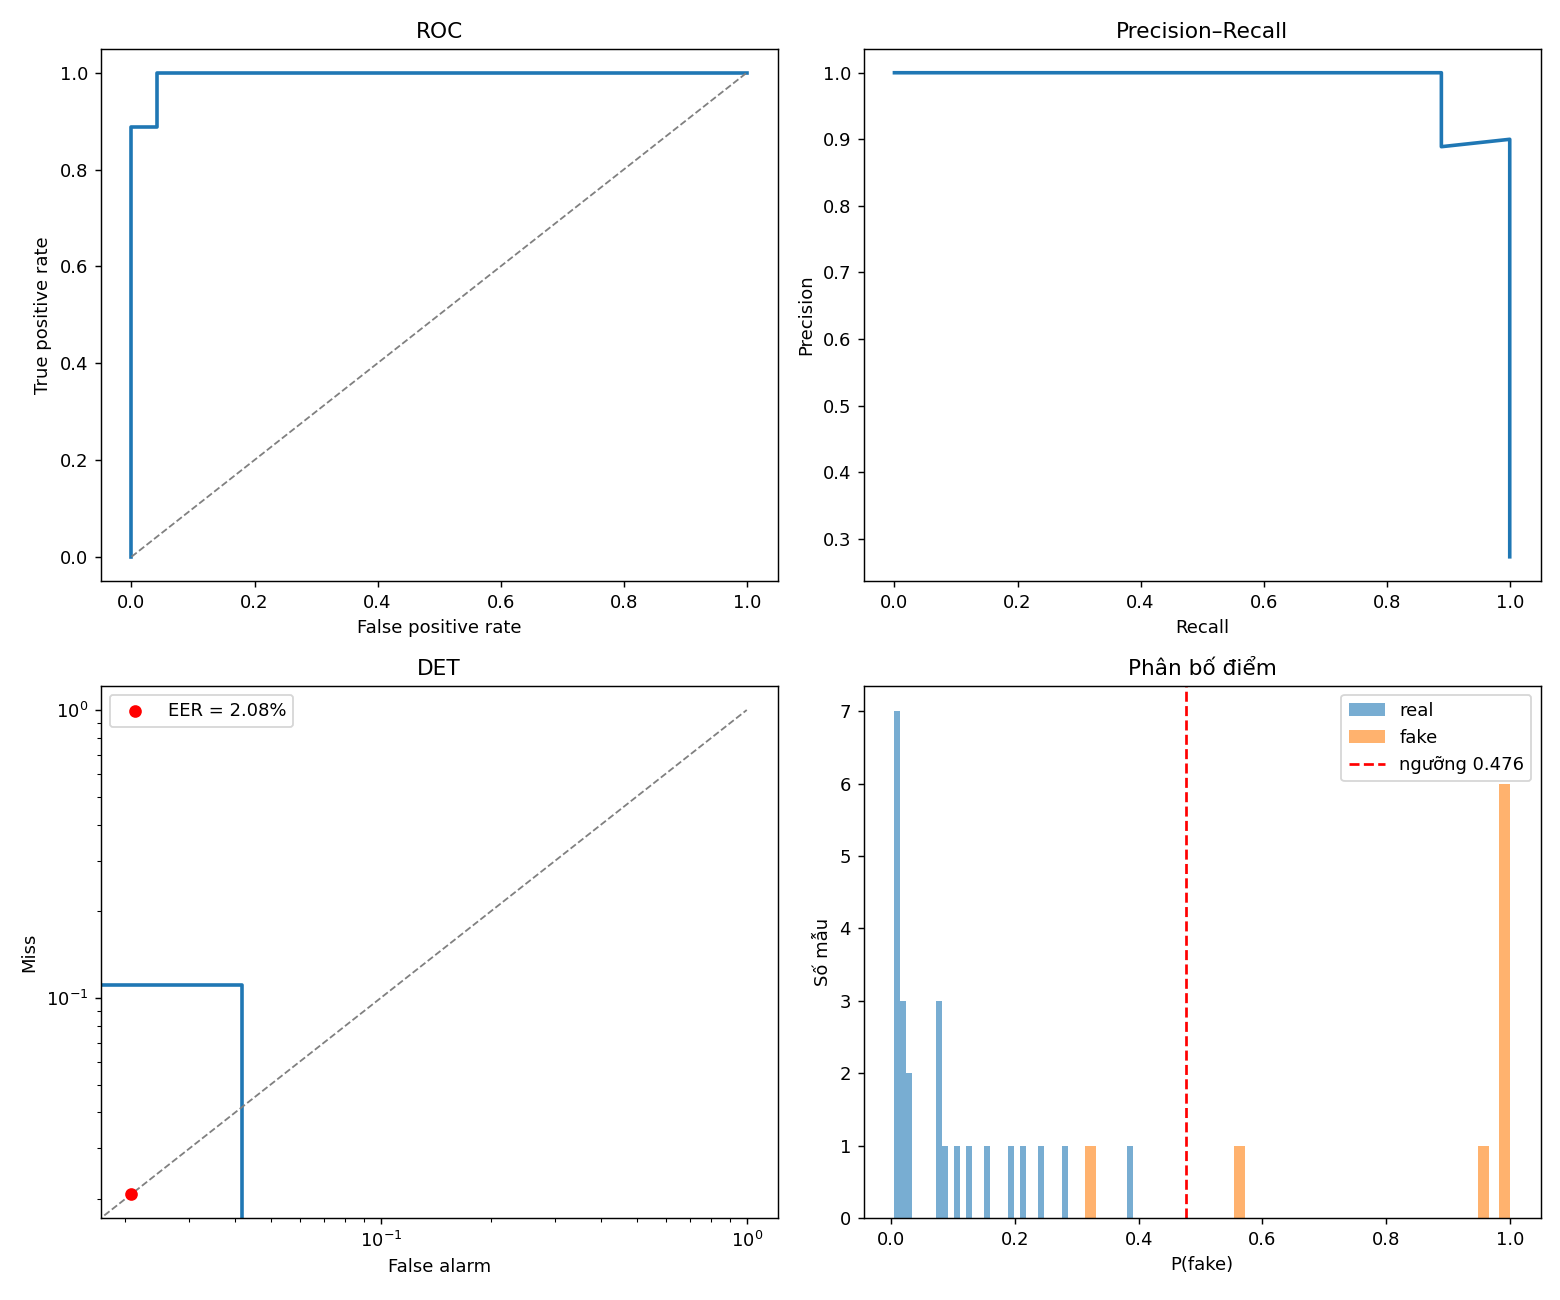

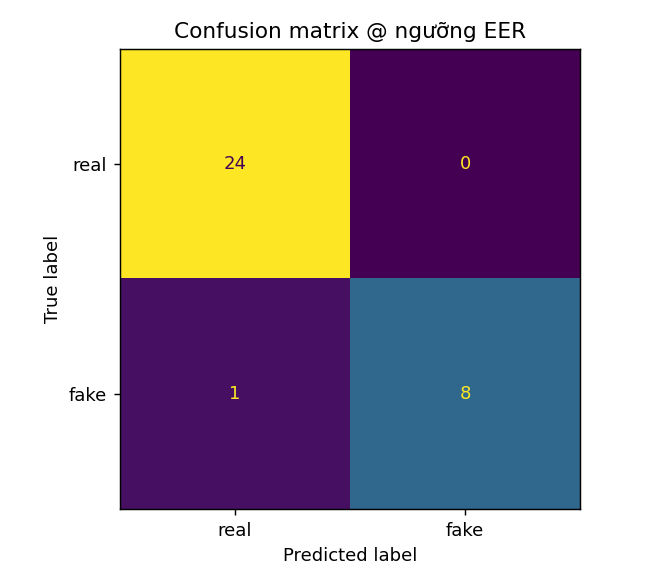

In [40]:
import json
from pathlib import Path
from IPython.display import Image, display

metrics = json.loads(Path("/kaggle/working/reports/metrics.json").read_text())
overall = metrics["overall"]
print(f"EER      : {overall['eer'] * 100:.2f}%      ← số đo chính")
print(f"ROC-AUC  : {overall['roc_auc']:.4f}")
print(f"min-DCF  : {overall['min_dcf']:.4f}")
print(f"Accuracy : {overall['accuracy'] * 100:.2f}%  (ngưỡng {overall['threshold']:.3f})")

print("\nTheo từng generator:")
for name, entry in metrics["by_generator"].items():
    if "eer_vs_all_real" in entry:
        print(f"  {name:<42} n={entry['n']:>5} · EER {entry['eer_vs_all_real'] * 100:6.2f}%"
              f" · bắt được {entry['detection_rate'] * 100:5.1f}%")
    elif "false_alarm_rate" in entry:
        print(f"  {name:<42} n={entry['n']:>5} · báo nhầm {entry['false_alarm_rate'] * 100:5.1f}%")

print("\nClean vs augmented:")
for name, entry in metrics["by_condition"].items():
    print(f"  {name:<12} n={entry['n']:>5} · điểm trung bình {entry['mean_score']:.3f}")

display(Image("/kaggle/working/reports/curves.png"))
display(Image("/kaggle/working/reports/confusion_matrix.png"))

## B4. Thử trên file bất kỳ + lưu mô hình

In [41]:
import glob

mau = sorted(glob.glob("/kaggle/working/corpus/audio/fake/piper/*/*.wav"))[:5]
mau += sorted(glob.glob("/kaggle/working/corpus/audio/real/*/*/*.wav"))[:5]
run("detect", *mau)

$ python -m aidetector detect /kaggle/working/corpus/audio/fake/piper/vi_vn-vais1000-medium/piper-2bc1d0d7e18a.wav /kaggle/working/corpus/audio/fake/piper/vi_vn-vais1000-medium/piper-3f746ce01844.wav /kaggle/working/corpus/audio/fake/piper/vi_vn-vais1000-medium/piper-719ca6343419.wav /kaggle/working/corpus/audio/fake/piper/vi_vn-vais1000-medium/piper-cdf37064b033.wav /kaggle/working/corpus/audio/fake/piper/vi_vn-vais1000-medium/piper-f4aff4625aef.wav /kaggle/working/corpus/audio/real/vivos/vivosdev01/vivos-061c7d3f1f36.wav /kaggle/working/corpus/audio/real/vivos/vivosdev01/vivos-279013b0846e.wav /kaggle/working/corpus/audio/real/vivos/vivosdev01/vivos-5f77dc51d222.wav /kaggle/working/corpus/audio/real/vivos/vivosdev01/vivos-743e1a207423.wav /kaggle/working/corpus/audio/real/vivos/vivosdev01/vivos-9497938513bf.wav -c configs/kaggle.yaml



09:30:35 INFO    aidetector.models | Head mlp · input_dim=768 · 198,657 tham số
09:30:35 INFO    aidetector.detect | Detector sẵn sàng · backbone=microsoft/wavlm-base-plus · device=cuda · ngưỡng=0.476
09:30:37 INFO    numexpr.utils | NumExpr defaulting to 4 threads.
09:30:42 INFO    aidetector.features.backbone | Nạp backbone wavlm (microsoft/wavlm-base-plus) trên cuda
09:30:42 INFO    httpx | HTTP Request: HEAD https://huggingface.co/microsoft/wavlm-base-plus/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
09:30:42 WARNING huggingface_hub.utils._http | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
09:30:42 INFO    httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/wavlm-base-plus/4c66d4806a428f2e922ccfa1a962776e232d487b/config.json "HTTP/1.1 200 OK"
09:30:42 INFO    httpx | HTTP Request: HEAD https://huggingface.co/microsoft/wavlm-base-plus/resolve/m

🔴 FAKE · P(fake)=0.997 · 3.03s · /kaggle/working/corpus/audio/fake/piper/vi_vn-vais1000-medium/piper-2bc1d0d7e18a.wav
🔴 FAKE · P(fake)=1.000 · 3.2s · /kaggle/working/corpus/audio/fake/piper/vi_vn-vais1000-medium/piper-3f746ce01844.wav
🔴 FAKE · P(fake)=0.957 · 3.16s · /kaggle/working/corpus/audio/fake/piper/vi_vn-vais1000-medium/piper-719ca6343419.wav
🔴 FAKE · P(fake)=0.997 · 3.37s · /kaggle/working/corpus/audio/fake/piper/vi_vn-vais1000-medium/piper-cdf37064b033.wav
🔴 FAKE · P(fake)=0.999 · 3.11s · /kaggle/working/corpus/audio/fake/piper/vi_vn-vais1000-medium/piper-f4aff4625aef.wav
🟢 REAL · P(fake)=0.014 · 5.21s · /kaggle/working/corpus/audio/real/vivos/vivosdev01/vivos-061c7d3f1f36.wav
🟢 REAL · P(fake)=0.031 · 3.43s · /kaggle/working/corpus/audio/real/vivos/vivosdev01/vivos-279013b0846e.wav
🟢 REAL · P(fake)=0.014 · 4.06s · /kaggle/working/corpus/audio/real/vivos/vivosdev01/vivos-5f77dc51d222.wav
🟢 REAL · P(fake)=0.275 · 4.54s · /kaggle/working/corpus/audio/real/vivos/vivosdev01/vivos-

True

In [42]:
import shutil
shutil.make_archive("/kaggle/working/model",          "zip", "/kaggle/working/checkpoints")
shutil.make_archive("/kaggle/working/reports_bundle", "zip", "/kaggle/working/reports")
!ls -lh /kaggle/working/*.zip

-rw-r--r-- 1 root root  27M Aug 13 09:29 /kaggle/working/corpus.zip
-rw-r--r-- 1 root root 727K Aug 13 09:30 /kaggle/working/model.zip
-rw-r--r-- 1 root root  90K Aug 13 09:30 /kaggle/working/reports_bundle.zip


---
### Vài nút chỉnh hay dùng

```python
# Đổi backbone (cache đặc trưng tách riêng nên không đụng nhau)
run("run", "features", "train", "evaluate", "--set", "features.backbone.name=wav2vec2")

# Đo khả năng tổng quát sang engine chưa từng thấy
run("split", "--holdout", "omnivoice")
run("run", "features", "train", "evaluate")

# Augment mạnh tay hơn nếu clean và augmented chênh lệch nhiều
run("augment", "--copies", 3, "--set", "augment.ops.codec.p=0.8")
```

Toàn bộ tham số nằm trong `configs/default.yaml` (bản Kaggle kế thừa nó qua
`configs/kaggle.yaml`) — xem bằng `!cat configs/default.yaml`.